# Chapter 4. Reflection

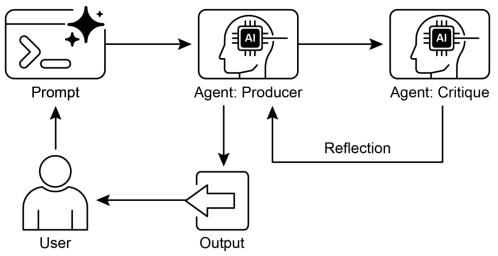

### Core Concept
- **Self-Correction**: The agent evaluates its own work, output, or internal state to improve performance.
- **Feedback Loop**: Unlike linear paths, reflection introduces a loop where an agent examines its result, finds issues, and generates a better version.
- **Iterative Refinement**: The process repeats—generate, critique, and refine—until the result is satisfactory.

### Why Use It?
- **Fix Suboptimal Output**: Initial AI responses are often incomplete or inaccurate; reflection helps recognize and fix these errors.
- **Higher Quality**: It leads to more accurate, coherent, and reliable outcomes by holding the model to specific standards.
- **Adaptability**: Moves agents from passive instruction-followers to sophisticated problem-solvers that "think" about their own work.

### The Producer-Critic Model
- **Separation of Roles**: Using two distinct logical roles (or two separate agents) yields the best results.
- **The Producer**: Focuses entirely on executing the task and creating the first draft (e.g., writing code).
- **The Critic**: Approached with a fresh perspective (e.g., "You are a meticulous fact-checker") to find flaws and suggest improvements.
- **Objective Feedback**: This separation prevents "cognitive bias" where an agent might overlook its own mistakes

### Hands-on Code Example

First, ensure you have the necessary libraries installed:
```
pip install langchain langchain-community langchain-openai
```

In [1]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv, find_dotenv
from IPython.display import display, Markdown

load_dotenv(find_dotenv(usecwd=True))
API_KEY  = os.environ.get("API_KEY")
BASE_URL = os.environ.get("BASE_URL")

Initialize the Language Model.

In [2]:
llm = ChatOpenAI(
    # model="glm-5-turbo",
    model="glm-4.5",
    api_key=API_KEY,
    base_url=BASE_URL,
    temperature=0
)

Define the prompt.

In [3]:
prompt_task = """
    Your task is to create a Python function named `calculate_factorial`. This function should do the following:
        1. Accept a single integer `n` as input.
        2. Calculate its factorial (n!).
        3. Include a clear docstring explaining what the function does.
        4. Handle edge cases: The factorial of 0 is 1.
        5. Handle invalid input: Raise a ValueError if the input is a negative number.
"""

def create_prompt_reflect(prompt_task, current_code):
    prompt_reflect = [
        SystemMessage(content="""
            You are a senior software engineer and an expert in Python.
            Your role is to perform a meticulous code review.
            Critically evaluate the provided Python code based on the original task requirements.
            Look for bugs, style issues, missing edge cases, and areas for improvement.
            If the code is perfect and meets all requirements, respond with the single phrase 'CODE_IS_PERFECT'.
            Otherwise, provide a bulleted list of your critiques.
        """),
        HumanMessage(content=f"Original Task:\n{prompt_task}\n\nCode to Review:\n{current_code}")
    ]
    return prompt_reflect

Define a multi-step AI reflection loop to progressively improve a Python function.

In [4]:
max_iterations = 3
concurrent_code = ""
message_history = [HumanMessage(content=prompt_task)]

for i in range(max_iterations):
    # 1 generate stage
    if i==0:
        print("\n>>> STAGE 1: GENERATING initial code...")
        response     = llm.invoke(message_history)
        current_code = response.content

    # 1 refine stage
    else:
        print("\n>>> STAGE 1: REFINING code based on previous critique...")
        message_history.append(HumanMessage(content="Please refine the code using the critiques provided."))
        response     = llm.invoke(message_history)
        current_code = response.content

        print("\n--- Generated Code (v" + str(i + 1) + ") ---\n" + current_code)
        message_history.append(response)

    # 2 reflect stage
    print("\n>>> STAGE 2: REFLECTING on the generated code...")
    prompt_reflect = create_prompt_reflect(prompt_task, current_code)
    critique = llm.invoke(prompt_reflect)
    critique = critique.content

    # 3 stopping condition
    if "CODE_IS_PERFECT" in critique:
        print("\n--- Critique ---\nNo further critiques found. The code is satisfactory.")
        break
        
    print("\n--- Critique ---\n" + critique)
    message_history.append(HumanMessage(content=f"Critique of the previous code:\n{critique}"))

print("\n" + "="*30 + " FINAL RESULT " + "="*30)
print("\nFinal refined code after the reflection process:\n")
display(Markdown(current_code))


>>> STAGE 1: GENERATING initial code...

>>> STAGE 2: REFLECTING on the generated code...

--- Critique ---
No further critiques found. The code is satisfactory.

============================== FINAL RESULT ==============================

Final refined code after the reflection process:




To solve this problem, we need to create a Python function that calculates the factorial of a given non-negative integer. The factorial of a number `n` (denoted as `n!`) is the product of all positive integers less than or equal to `n`. The solution must handle edge cases such as `n = 0` and invalid inputs like negative numbers.

### Approach
1. **Problem Analysis**: The factorial function is defined for non-negative integers. For `n = 0`, the factorial is 1. For any negative integer, the factorial is undefined, so we need to handle such cases by raising a `ValueError`.
2. **Algorithm Selection**: We use an iterative approach to compute the factorial. This method is efficient and avoids the overhead of recursion, especially for large values of `n`.
3. **Edge Cases Handling**: 
   - If `n` is 0, return 1.
   - If `n` is negative, raise a `ValueError`.
4. **Complexity Analysis**: The time complexity is O(n) since we iterate from 1 to `n` once to compute the product. The space complexity is O(1) as we only use a single variable to store the result.

### Solution Code
```python
def calculate_factorial(n):
    """
    Calculate the factorial of a non-negative integer n.

    The factorial of a number n (denoted as n!) is the product of all positive integers
    less than or equal to n. For example, 5! = 5 * 4 * 3 * 2 * 1 = 120.
    
    Parameters:
    n (int): The non-negative integer for which factorial is to be computed.
    
    Returns:
    int: The factorial of n.
    
    Raises:
    ValueError: If n is a negative integer.
    
    Examples:
    >>> calculate_factorial(5)
    120
    >>> calculate_factorial(0)
    1
    >>> calculate_factorial(1)
    1
    >>> calculate_factorial(-1)
    Traceback (most recent call last):
    ...
    ValueError: Factorial is undefined for negative numbers.
    """
    if n < 0:
        raise ValueError("Factorial is undefined for negative numbers.")
    result = 1
    for i in range(1, n + 1):
        result *= i
    return result
```

### Explanation
1. **Function Definition**: The function `calculate_factorial` is defined with a single parameter `n`.
2. **Docstring**: The docstring provides a clear explanation of the function's purpose, parameters, return value, and exceptions. It also includes examples for better understanding.
3. **Input Validation**: The function first checks if `n` is negative. If so, it raises a `ValueError` with an appropriate message.
4. **Factorial Calculation**: For non-negative inputs, the function initializes `result` to 1. It then iterates from 1 to `n` (inclusive), multiplying each integer with `result` to compute the factorial.
5. **Return Result**: The computed factorial is returned after the loop completes.

This approach efficiently handles all valid inputs and provides clear error messages for invalid inputs, ensuring robustness and correctness.